In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2717s 16us/step
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

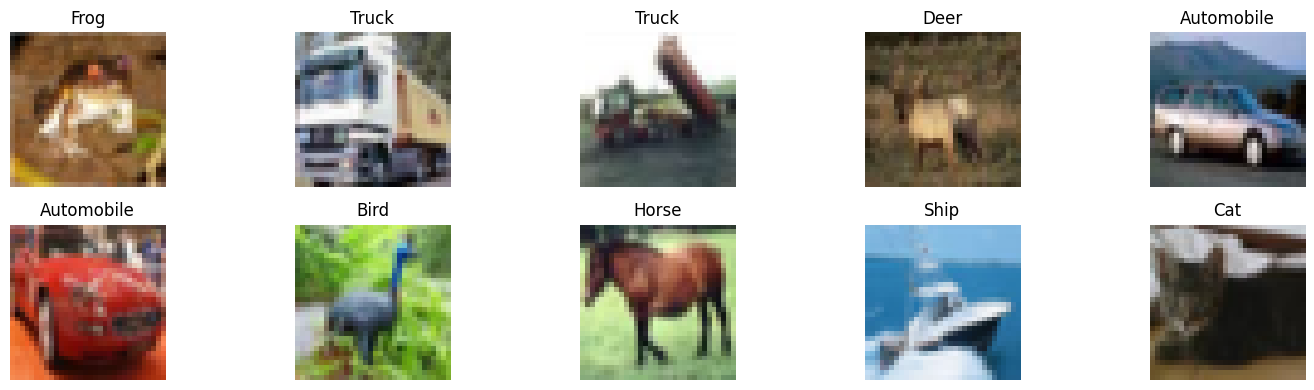

In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

plt.figure(figsize=(15,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
train_ds = train_ds.shuffle(10000)

train_ds = train_ds.map(
    lambda x, y: (tf.image.resize(x, (IMG_SIZE, IMG_SIZE)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))

test_ds = test_ds.map(
    lambda x, y: (tf.image.resize(x, (IMG_SIZE, IMG_SIZE)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

outputs = Dense(10, activation="softmax")(x)

model = Model(inputs=base_model.input,
              outputs=outputs)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)






Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 338s 207ms/step - accuracy: 0.3981 - loss: 1.6749 - val_accuracy: 0.5142 - val_loss: 1.4026
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 324s 207ms/step - accuracy: 0.5112 - loss: 1.3812 - val_accuracy: 0.5655 - val_loss: 1.2460
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 323s 207ms/step - accuracy: 0.5449 - loss: 1.2883 - val_accuracy: 0.5789 - val_loss: 1.1797
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 323s 207ms/step - accuracy: 0.5603 - loss: 1.2388 - val_accuracy: 0.6002 - val_loss: 1.1364
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 384s 208ms/step - accuracy: 0.5757 - loss: 1.2058 - val_accuracy: 0.5999 - val_loss: 1.1333
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 323s 207ms/step - accuracy: 0.5832 - loss: 1.1820 - val_accuracy: 0.6261 - val_loss: 1.0617
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 324s 207ms/step - accuracy: 0.5913 - loss: 1.1615 - val_accuracy: 0.6191 - val_loss: 1.0764
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 323s 207ms/step - ac

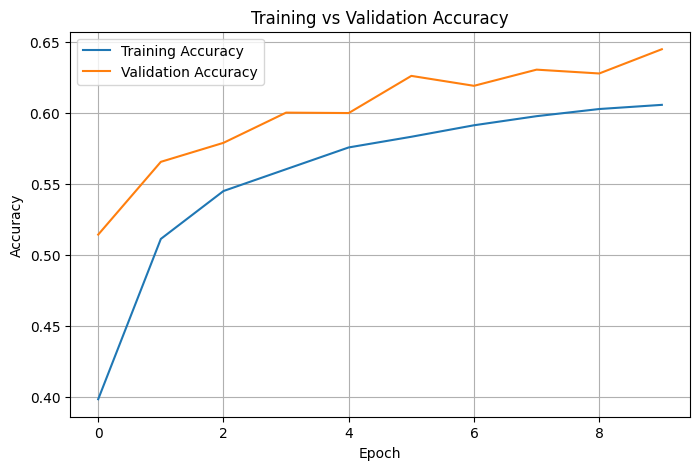

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

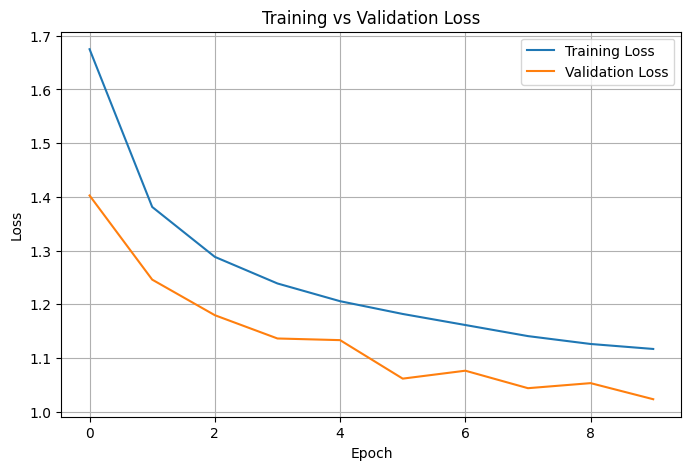

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - accuracy: 0.6449 - loss: 1.0233
Test Loss : 1.023335576057434
Test Accuracy : 0.6449000239372253


In [ ]:
import numpy as np

y_pred_probs = model.predict(test_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.6449
Precision : 0.652200384597671
Recall : 0.6449
F1 Score : 0.6458772460302175


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.78      0.69      0.73      1000
  Automobile       0.73      0.77      0.75      1000
        Bird       0.60      0.53      0.57      1000
         Cat       0.49      0.44      0.46      1000
        Deer       0.51      0.66      0.58      1000
         Dog       0.51      0.58      0.54      1000
        Frog       0.69      0.63      0.66      1000
       Horse       0.65      0.68      0.66      1000
        Ship       0.75      0.79      0.77      1000
       Truck       0.82      0.69      0.75      1000

    accuracy                           0.64     10000
   macro avg       0.65      0.64      0.65     10000
weighted avg       0.65      0.64      0.65     10000



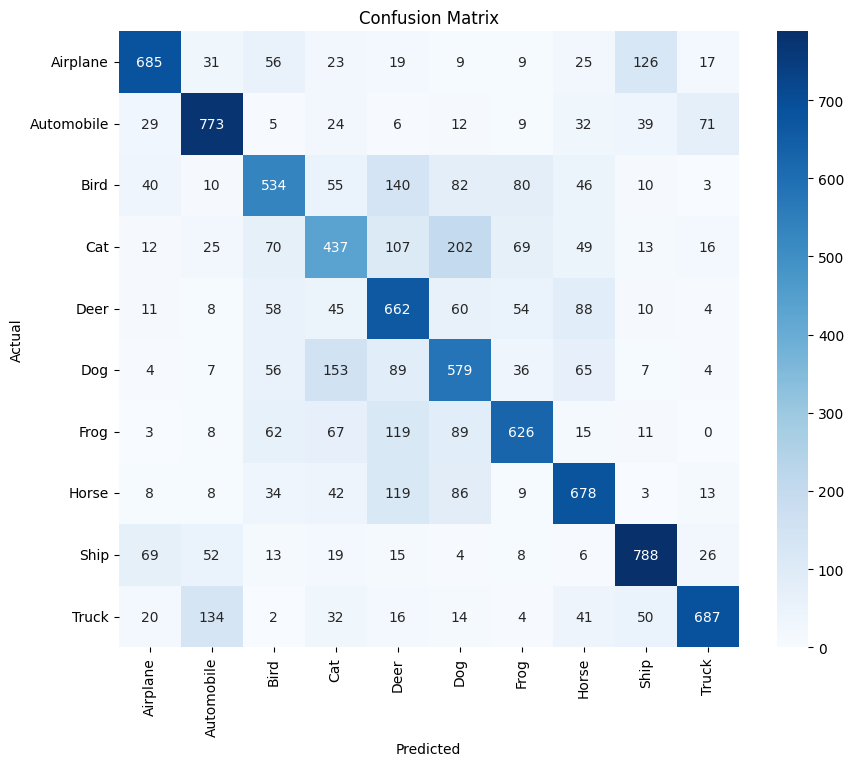

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

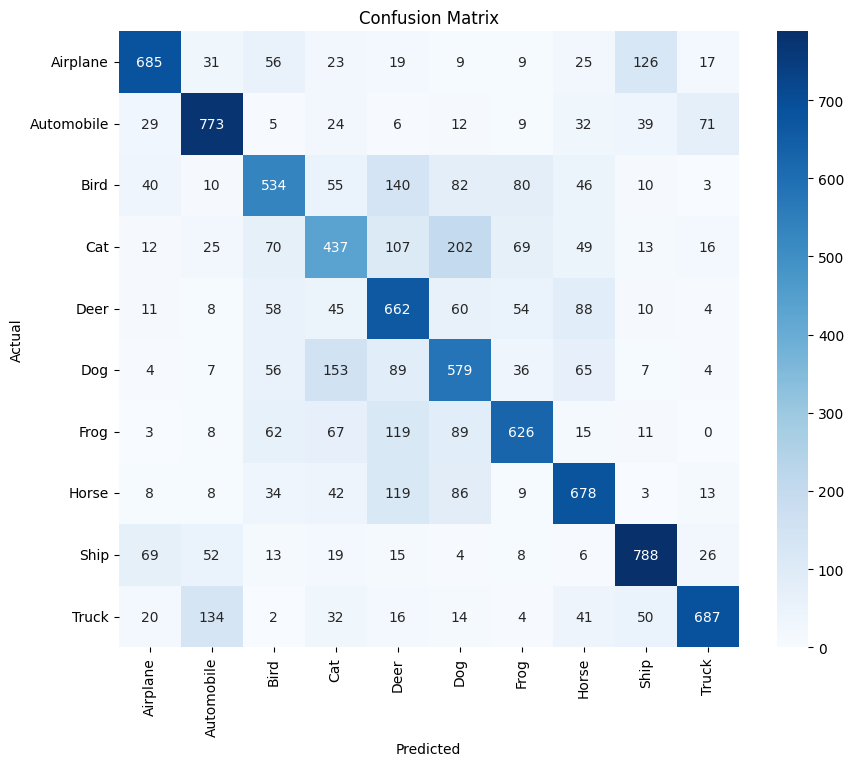

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Unfreeze the last 4 layers of the base model
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

In [ ]:
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fine_history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 381s 239ms/step - accuracy: 0.6743 - loss: 0.9340 - val_accuracy: 0.7475 - val_loss: 0.7396
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 369s 236ms/step - accuracy: 0.7424 - loss: 0.7408 - val_accuracy: 0.7656 - val_loss: 0.6719
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 370s 237ms/step - accuracy: 0.7794 - loss: 0.6330 - val_accuracy: 0.7926 - val_loss: 0.6068
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 370s 237ms/step - accuracy: 0.8069 - loss: 0.5513 - val_accuracy: 0.8092 - val_loss: 0.5612
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 370s 236ms/step - accuracy: 0.8313 - loss: 0.4866 - val_accuracy: 0.8049 - val_loss: 0.5792


In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Final Test Loss :", loss)
print("Final Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.8049 - loss: 0.5792
Final Test Loss : 0.5792401432991028
Final Test Accuracy : 0.8048999905586243


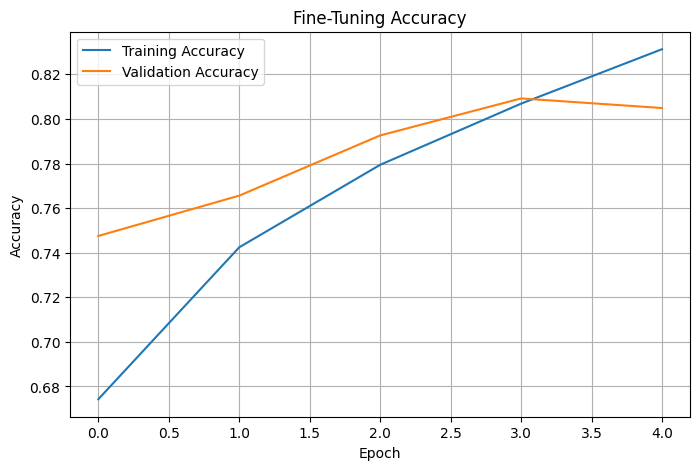

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(fine_history.history['accuracy'], label='Training Accuracy')
plt.plot(fine_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

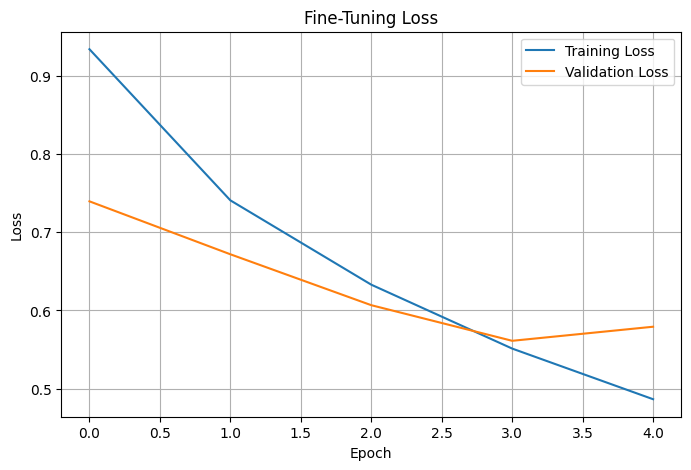

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(fine_history.history['loss'], label='Training Loss')
plt.plot(fine_history.history['val_loss'], label='Validation Loss')

plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.save("vgg16_cifar10_transfer_learning.keras")

In [ ]:
print("=" * 50)
print("FINAL VGG16 CIFAR-10 RESULTS")
print("=" * 50)

print(f"Test Accuracy  : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"Test Loss       : {loss:.4f}")

FINAL VGG16 CIFAR-10 RESULTS
Test Accuracy  : 0.8049
Precision       : 0.6522
Recall          : 0.6449
F1 Score        : 0.6459
Test Loss       : 0.5792


In [ ]:
# Freeze everything first
base_model.trainable = False

# Unfreeze the last convolutional block (block5)
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

# Check trainable layers
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name, "-> Trainable")

block5_conv1 -> Trainable
block5_conv2 -> Trainable
block5_conv3 -> Trainable
block5_pool -> Trainable


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 376s 238ms/step - accuracy: 0.8479 - loss: 0.4358 - val_accuracy: 0.8237 - val_loss: 0.5338
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 369s 236ms/step - accuracy: 0.8651 - loss: 0.3853 - val_accuracy: 0.8300 - val_loss: 0.5069
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 369s 236ms/step - accuracy: 0.8805 - loss: 0.3464 - val_accuracy: 0.8371 - val_loss: 0.4997
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 369s 236ms/step - accuracy: 0.8928 - loss: 0.3098 - val_accuracy: 0.8321 - val_loss: 0.5191
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 369s 236ms/step - accuracy: 0.9014 - loss: 0.2847 - val_accuracy: 0.8357 - val_loss: 0.5031


In [ ]:
fine_test_loss, fine_test_accuracy = model.evaluate(test_ds)

print("Fine-Tuned Test Loss     :", fine_test_loss)
print("Fine-Tuned Test Accuracy :", fine_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.8357 - loss: 0.5031
Fine-Tuned Test Loss     : 0.5030564665794373
Fine-Tuned Test Accuracy : 0.8356999754905701


In [ ]:
print("Before Fine-Tuning Accuracy :", test_accuracy)
print("After Fine-Tuning Accuracy  :", fine_test_accuracy)

Before Fine-Tuning Accuracy : 0.6449000239372253
After Fine-Tuning Accuracy  : 0.8356999754905701


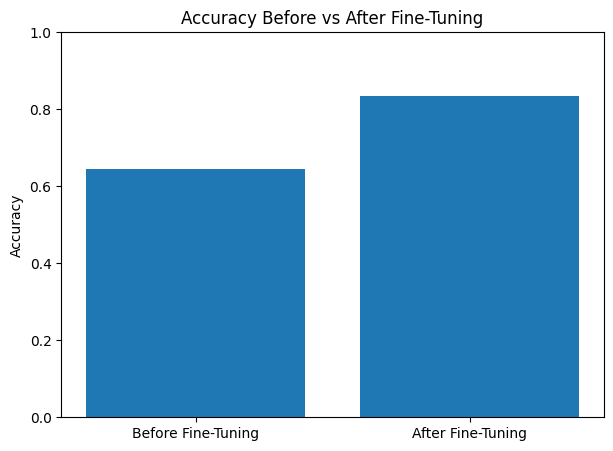

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    ["Before Fine-Tuning", "After Fine-Tuning"],
    [test_accuracy, fine_test_accuracy]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Before vs After Fine-Tuning")
plt.ylim(0, 1)

plt.show()

In [ ]:
y_pred_probs_final = model.predict(test_ds)

y_pred_final = np.argmax(y_pred_probs_final, axis=1)

y_true_final = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 173ms/step


In [ ]:
final_accuracy = accuracy_score(
    y_true_final,
    y_pred_final
)

final_precision = precision_score(
    y_true_final,
    y_pred_final,
    average="weighted"
)

final_recall = recall_score(
    y_true_final,
    y_pred_final,
    average="weighted"
)

final_f1 = f1_score(
    y_true_final,
    y_pred_final,
    average="weighted"
)

print("FINAL RESULTS")
print("-------------------------")
print("Accuracy  :", final_accuracy)
print("Precision :", final_precision)
print("Recall    :", final_recall)
print("F1 Score  :", final_f1)

FINAL RESULTS
-------------------------
Accuracy  : 0.8357
Precision : 0.839646120171563
Recall    : 0.8357
F1 Score  : 0.8347772522602926


In [ ]:
print(
    classification_report(
        y_true_final,
        y_pred_final,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.87      0.89      0.88      1000
  Automobile       0.94      0.90      0.92      1000
        Bird       0.86      0.74      0.79      1000
         Cat       0.73      0.64      0.68      1000
        Deer       0.74      0.87      0.80      1000
         Dog       0.74      0.76      0.75      1000
        Frog       0.77      0.92      0.84      1000
       Horse       0.95      0.77      0.85      1000
        Ship       0.90      0.94      0.92      1000
       Truck       0.88      0.93      0.91      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.83     10000
weighted avg       0.84      0.84      0.83     10000



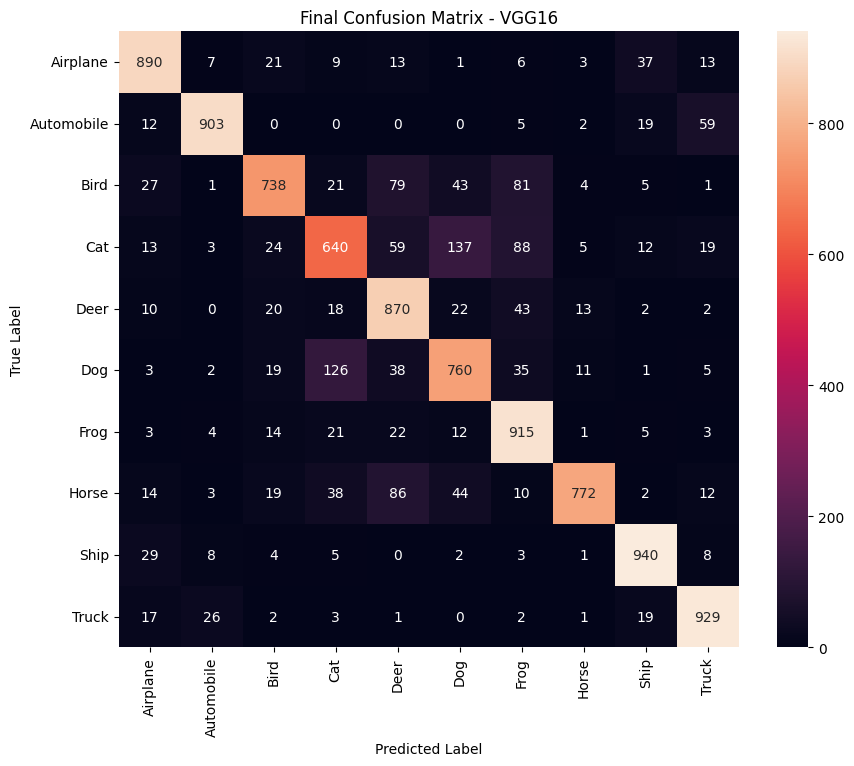

In [ ]:
cm_final = confusion_matrix(
    y_true_final,
    y_pred_final
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Confusion Matrix - VGG16")

plt.show()

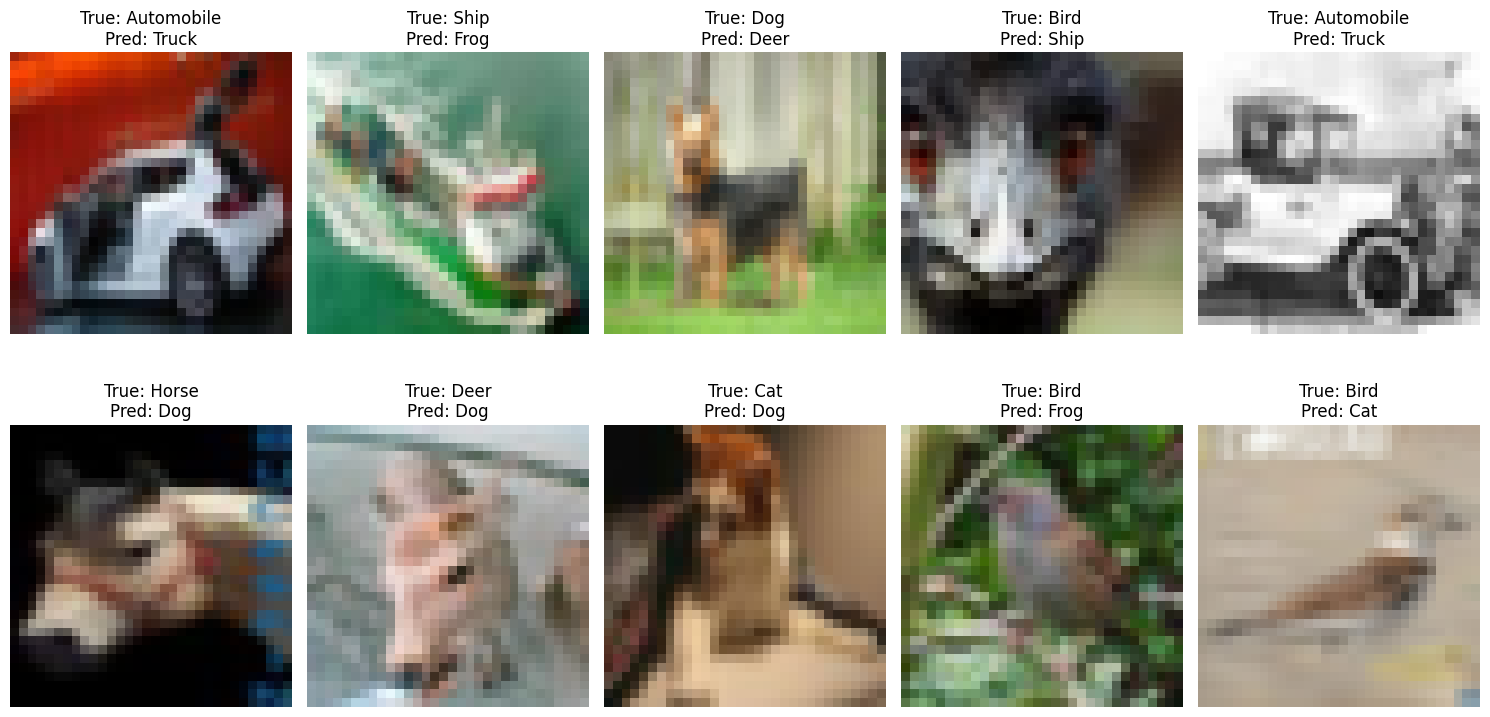

In [ ]:
misclassified_final = np.where(
    y_true_final != y_pred_final
)[0]

plt.figure(figsize=(15,8))

for i, idx in enumerate(misclassified_final[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[idx])

    plt.title(
        f"True: {class_names[y_true_final[idx]]}\n"
        f"Pred: {class_names[y_pred_final[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

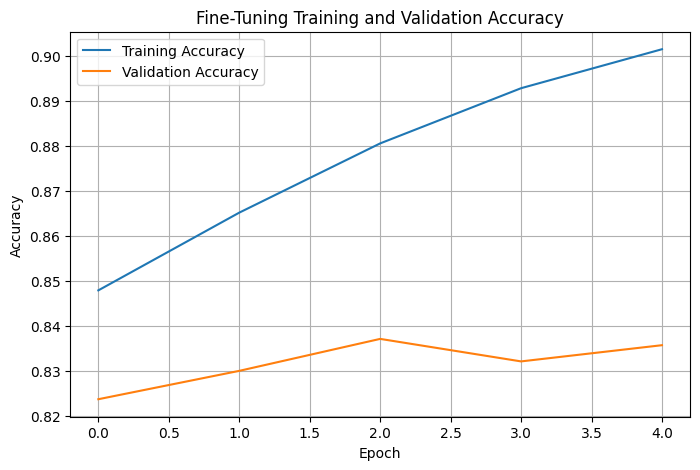

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    fine_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

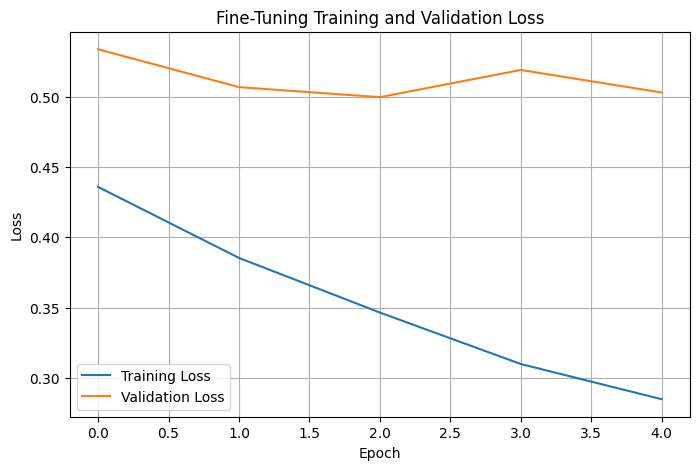

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    fine_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
total_params = model.count_params()

trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.trainable_weights
])

non_trainable_params = total_params - trainable_params

print("Total Parameters     :", total_params)
print("Trainable Parameters :", trainable_params)
print("Non-Trainable        :", non_trainable_params)

Total Parameters     : 14848586
Trainable Parameters : 7213322
Non-Trainable        : 7635264


In [ ]:
# Fine-tuning: unfreeze only the last convolutional block

base_model.trainable = False

for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers:
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [ ]:
import time

start_time = time.time()

fine_history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

end_time = time.time()

fine_tuning_time = end_time - start_time

print("Fine-Tuning Time:", fine_tuning_time, "seconds")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 385s 239ms/step - accuracy: 0.9281 - loss: 0.2105 - val_accuracy: 0.8499 - val_loss: 0.4789
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 363s 232ms/step - accuracy: 0.9346 - loss: 0.1910 - val_accuracy: 0.8483 - val_loss: 0.4869
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 355s 227ms/step - accuracy: 0.9414 - loss: 0.1742 - val_accuracy: 0.8435 - val_loss: 0.4989
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 352s 225ms/step - accuracy: 0.9476 - loss: 0.1570 - val_accuracy: 0.8533 - val_loss: 0.4731
Epoch 5/5
 397/1563 ━━━━━━━━━━━━━━━━━━━━ 3:46 194ms/step - accuracy: 0.9521 - loss: 0.1421

In [ ]:
fine_test_loss, fine_test_accuracy = model.evaluate(test_ds)

print("Fine-Tuned Test Loss     :", fine_test_loss)
print("Fine-Tuned Test Accuracy :", fine_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.8457 - loss: 0.5243
Fine-Tuned Test Loss     : 0.5242509245872498
Fine-Tuned Test Accuracy : 0.8457000255584717


In [ ]:
print("Before Fine-Tuning Accuracy :", test_accuracy)
print("After Fine-Tuning Accuracy  :", fine_test_accuracy)

Before Fine-Tuning Accuracy : 0.6449000239372253
After Fine-Tuning Accuracy  : 0.8457000255584717


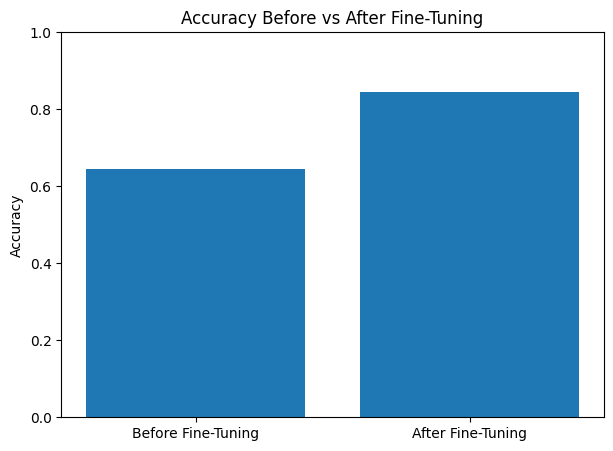

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    ["Before Fine-Tuning", "After Fine-Tuning"],
    [test_accuracy, fine_test_accuracy]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Before vs After Fine-Tuning")
plt.ylim(0, 1)

plt.show()

In [ ]:
y_pred_probs_final = model.predict(test_ds)

y_pred_final = np.argmax(y_pred_probs_final, axis=1)
y_true_final = np.argmax(y_test_cat, axis=1)

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step
Predictions generated successfully.


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

final_accuracy = accuracy_score(
    y_true_final,
    y_pred_final
)

final_precision = precision_score(
    y_true_final,
    y_pred_final,
    average="weighted"
)

final_recall = recall_score(
    y_true_final,
    y_pred_final,
    average="weighted"
)

final_f1 = f1_score(
    y_true_final,
    y_pred_final,
    average="weighted"
)

print("Final Accuracy  :", final_accuracy)
print("Final Precision :", final_precision)
print("Final Recall    :", final_recall)
print("Final F1-Score  :", final_f1)

Final Accuracy  : 0.8457
Final Precision : 0.8475175713122116
Final Recall    : 0.8457
Final F1-Score  : 0.8448983039304443


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_final,
        y_pred_final,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.85      0.91      0.88      1000
  Automobile       0.89      0.93      0.91      1000
        Bird       0.81      0.83      0.82      1000
         Cat       0.74      0.69      0.71      1000
        Deer       0.75      0.88      0.81      1000
         Dog       0.84      0.71      0.77      1000
        Frog       0.87      0.88      0.87      1000
       Horse       0.88      0.87      0.87      1000
        Ship       0.89      0.94      0.91      1000
       Truck       0.96      0.83      0.89      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.84     10000
weighted avg       0.85      0.85      0.84     10000



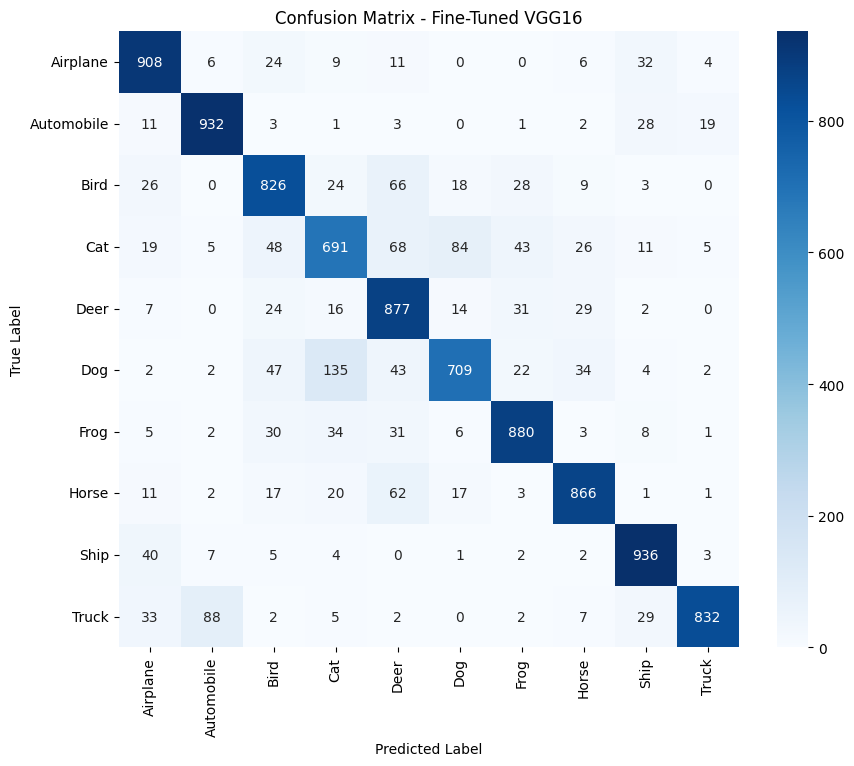

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_final = confusion_matrix(
    y_true_final,
    y_pred_final
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned VGG16")

plt.show()

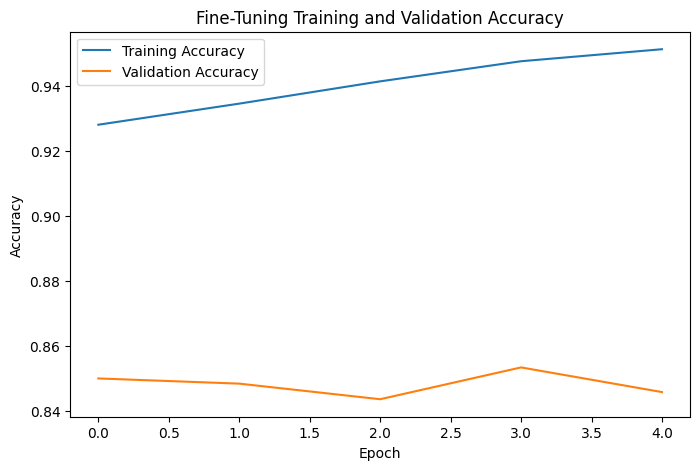

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    fine_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Training and Validation Accuracy")

plt.legend()
plt.show()

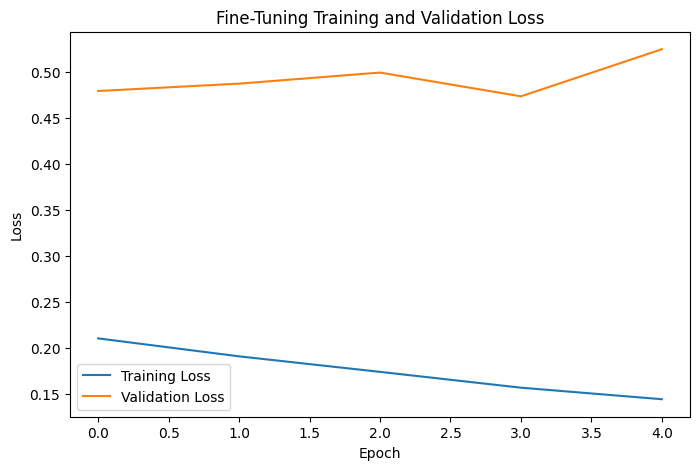

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    fine_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Training and Validation Loss")

plt.legend()
plt.show()

In [ ]:
total_params = model.count_params()

trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.trainable_weights
])

print("Total Parameters    :", total_params)
print("Trainable Parameters:", trainable_params)

Total Parameters    : 14848586
Trainable Parameters: 7213322


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Fine-Tuning Time (seconds)",
        "Total Parameters"
    ],

    "Value": [
        fine_history.history["accuracy"][-1],
        fine_test_accuracy,
        final_precision,
        final_recall,
        final_f1,
        fine_tuning_time,
        total_params
    ]
})

print(results)

                       Metric         Value
0           Training Accuracy  9.513200e-01
1            Testing Accuracy  8.457000e-01
2                   Precision  8.475176e-01
3                      Recall  8.457000e-01
4                    F1-Score  8.448983e-01
5  Fine-Tuning Time (seconds)  1.808964e+03
6            Total Parameters  1.484859e+07


In [ ]:
model.save("VGG16_CIFAR10_FineTuned.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# ============================================================
# HYPERPARAMETER STUDY - EXPERIMENT 4
# VGG16 Transfer Learning on CIFAR-10
# 2 epochs per experiment
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import time

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    Input,
    Resizing,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD


# ------------------------------------------------------------
# 1. USE A SMALL SUBSET FOR FAST HYPERPARAMETER STUDY
# ------------------------------------------------------------

# 10,000 training images and 2,000 test images
# This is ONLY for the hyperparameter comparison.

x_hp_train = x_train[:10000]
y_hp_train = y_train[:10000]

x_hp_test = x_test[:2000]
y_hp_test = y_test[:2000]

print("Hyperparameter study dataset:")
print("Training:", x_hp_train.shape)
print("Testing :", x_hp_test.shape)


# ------------------------------------------------------------
# 2. FUNCTION TO CREATE A FRESH VGG16 MODEL
# ------------------------------------------------------------

def create_vgg16_model(
    learning_rate=0.001,
    optimizer_name="Adam",
    dense_units=128,
    partial_freeze=False
):

    # VGG16 pretrained on ImageNet
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze everything first
    base_model.trainable = False

    # Partial freezing = unfreeze last convolution block
    if partial_freeze:

        for layer in base_model.layers:

            if layer.name.startswith("block5"):
                layer.trainable = True


    # Input
    inputs = Input(shape=(32, 32, 3))

    # Resize CIFAR-10 images
    x = Resizing(224, 224)(inputs)

    # VGG16 base
    x = base_model(x, training=False)

    # Global Average Pooling
    x = GlobalAveragePooling2D()(x)

    # Dense layer
    x = Dense(
        dense_units,
        activation="relu"
    )(x)

    x = Dropout(0.2)(x)

    # Output layer
    outputs = Dense(
        10,
        activation="softmax"
    )(x)

    model = Model(
        inputs,
        outputs
    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    if optimizer_name == "Adam":

        optimizer = Adam(
            learning_rate=learning_rate
        )

    else:

        optimizer = SGD(
            learning_rate=learning_rate
        )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 3. RUN ONE EXPERIMENT
# ------------------------------------------------------------

def run_experiment(
    experiment_name,
    learning_rate=0.001,
    batch_size=32,
    optimizer_name="Adam",
    dense_units=128,
    partial_freeze=False
):

    print("\n" + "=" * 60)
    print("Running:", experiment_name)
    print("=" * 60)

    print(
        "LR:", learning_rate,
        "| Batch:", batch_size,
        "| Optimizer:", optimizer_name,
        "| Dense:", dense_units,
        "| Partial Freeze:", partial_freeze
    )

    # Create fresh model
    model = create_vgg16_model(
        learning_rate=learning_rate,
        optimizer_name=optimizer_name,
        dense_units=dense_units,
        partial_freeze=partial_freeze
    )

    # Start timer
    start = time.time()

    # Train for ONLY 2 epochs
    history = model.fit(
        x_hp_train,
        y_hp_train,
        validation_data=(
            x_hp_test,
            y_hp_test
        ),
        epochs=2,
        batch_size=batch_size,
        verbose=1
    )

    end = time.time()

    training_time = end - start

    # Best validation accuracy
    best_val_accuracy = max(
        history.history["val_accuracy"]
    )

    final_train_accuracy = (
        history.history["accuracy"][-1]
    )

    print(
        "Best Validation Accuracy:",
        best_val_accuracy
    )

    print(
        "Training Time:",
        round(training_time, 2),
        "seconds"
    )

    return {
        "Experiment": experiment_name,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Optimizer": optimizer_name,
        "Dense Units": dense_units,
        "Partial Freeze": partial_freeze,
        "Training Accuracy": final_train_accuracy,
        "Validation Accuracy": best_val_accuracy,
        "Training Time (sec)": training_time
    }


# ------------------------------------------------------------
# 4. RUN HYPERPARAMETER EXPERIMENTS
# ------------------------------------------------------------

results = []


# ============================================================
# LEARNING RATE
# ============================================================

results.append(
    run_experiment(
        "Learning Rate 0.001",
        learning_rate=0.001
    )
)

results.append(
    run_experiment(
        "Learning Rate 0.0001",
        learning_rate=0.0001
    )
)


# ============================================================
# BATCH SIZE
# ============================================================

results.append(
    run_experiment(
        "Batch Size 16",
        batch_size=16
    )
)

results.append(
    run_experiment(
        "Batch Size 32",
        batch_size=32
    )
)

results.append(
    run_experiment(
        "Batch Size 64",
        batch_size=64
    )
)


# ============================================================
# OPTIMIZER
# ============================================================

results.append(
    run_experiment(
        "Optimizer Adam",
        optimizer_name="Adam"
    )
)

results.append(
    run_experiment(
        "Optimizer SGD",
        optimizer_name="SGD"
    )
)


# ============================================================
# DENSE UNITS
# ============================================================

results.append(
    run_experiment(
        "Dense Units 128",
        dense_units=128
    )
)

results.append(
    run_experiment(
        "Dense Units 256",
        dense_units=256
    )
)


# ============================================================
# FROZEN VS PARTIAL LAYERS
# ============================================================

results.append(
    run_experiment(
        "All Layers Frozen",
        partial_freeze=False
    )
)

results.append(
    run_experiment(
        "Partial Freezing",
        partial_freeze=True
    )
)


# ------------------------------------------------------------
# 5. FINAL RESULTS TABLE
# ------------------------------------------------------------

hyperparameter_results = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("FINAL HYPERPARAMETER STUDY RESULTS")
print("=" * 80)

display(hyperparameter_results)

Hyperparameter study dataset:
Training: (10000, 32, 32, 3)
Testing : (2000, 32, 32, 3)

Running: Learning Rate 0.001
LR: 0.001 | Batch: 32 | Optimizer: Adam | Dense: 128 | Partial Freeze: False
Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 194ms/step - accuracy: 0.2889 - loss: 2.0007 - val_accuracy: 0.4055 - val_loss: 1.7500
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 208ms/step - accuracy: 0.4052 - loss: 1.6763 - val_accuracy: 0.4405 - val_loss: 1.5792
Best Validation Accuracy: 0.4404999911785126
Training Time: 129.21 seconds

Running: Learning Rate 0.0001
LR: 0.0001 | Batch: 32 | Optimizer: Adam | Dense: 128 | Partial Freeze: False
Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 206ms/step - accuracy: 0.1558 - loss: 2.2684 - val_accuracy: 0.2595 - val_loss: 2.1710
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 196ms/step - accuracy: 0.2432 - loss: 2.1331 - val_accuracy: 0.3420 - val_loss: 2.0643
Best Validation Accuracy: 0.34200000762939453
Training Time: 128.83 seconds

Running: Batch Size 16
LR

,Experiment,Learning Rate,Batch Size,Optimizer,Dense Units,Partial Freeze,Training Accuracy,Validation Accuracy,Training Time (sec)
0,Learning Rate 0.001,0.0010,32,Adam,128,False,0.4052,0.4405,129.208178
1,Learning Rate 0.0001,0.0001,32,Adam,128,False,0.2432,0.3420,128.831046
2,Batch Size 16,0.0010,16,Adam,128,False,0.4369,0.4805,148.277598
3,Batch Size 32,0.0010,32,Adam,128,False,0.4181,0.4665,128.868405
4,Batch Size 64,0.0010,64,Adam,128,False,0.3919,0.4465,136.734805
5,Optimizer Adam,0.0010,32,Adam,128,False,0.4143,0.4755,133.433630
6,Optimizer SGD,0.0010,32,SGD,128,False,0.1062,0.1340,131.934294
7,Dense Units 128,0.0010,32,Adam,128,False,0.4154,0.4550,133.021915
8,Dense Units 256,0.0010,32,Adam,256,False,0.4357,0.4405,136.378531
9,All Layers Frozen,0.0010,32,Adam,128,False,0.4055,0.4650,133.874977


In [ ]:
# ============================================================
# CNN ARCHITECTURE COMPARISON TABLE
# ============================================================

# Get VGG16 results from our completed experiment
vgg16_accuracy = fine_test_accuracy
vgg16_time = fine_tuning_time

comparison = pd.DataFrame({
    "Model": [
        "LeNet-5",
        "AlexNet",
        "VGG16",
        "GoogleNet",
        "ResNet50"
    ],

    "Parameters": [
        "60K",
        "61M",
        "138M",
        "6.8M",
        "25.6M"
    ],

    "Accuracy (%)": [
        "Not Implemented",
        "Not Implemented",
        round(vgg16_accuracy * 100, 2),
        "Not Implemented",
        "Not Implemented"
    ],

    "Training Time": [
        "Not Implemented",
        "Not Implemented",
        round(vgg16_time, 2),
        "Not Implemented",
        "Not Implemented"
    ]
})

display(comparison)

,Model,Parameters,Accuracy (%),Training Time
0,LeNet-5,60K,Not Implemented,Not Implemented
1,AlexNet,61M,Not Implemented,Not Implemented
2,VGG16,138M,84.57,1808.96
3,GoogleNet,6.8M,Not Implemented,Not Implemented
4,ResNet50,25.6M,Not Implemented,Not Implemented


In [ ]:
# Save hyperparameter study results

hyperparameter_results.to_csv(
    "hyperparameter_results.csv",
    index=False
)

print("Hyperparameter results saved!")
display(hyperparameter_results)

Hyperparameter results saved!


,Experiment,Learning Rate,Batch Size,Optimizer,Dense Units,Partial Freeze,Training Accuracy,Validation Accuracy,Training Time (sec)
0,Learning Rate 0.001,0.0010,32,Adam,128,False,0.4052,0.4405,129.208178
1,Learning Rate 0.0001,0.0001,32,Adam,128,False,0.2432,0.3420,128.831046
2,Batch Size 16,0.0010,16,Adam,128,False,0.4369,0.4805,148.277598
3,Batch Size 32,0.0010,32,Adam,128,False,0.4181,0.4665,128.868405
4,Batch Size 64,0.0010,64,Adam,128,False,0.3919,0.4465,136.734805
5,Optimizer Adam,0.0010,32,Adam,128,False,0.4143,0.4755,133.433630
6,Optimizer SGD,0.0010,32,SGD,128,False,0.1062,0.1340,131.934294
7,Dense Units 128,0.0010,32,Adam,128,False,0.4154,0.4550,133.021915
8,Dense Units 256,0.0010,32,Adam,256,False,0.4357,0.4405,136.378531
9,All Layers Frozen,0.0010,32,Adam,128,False,0.4055,0.4650,133.874977


In [ ]:
# ============================================================
# EXPERIMENT 4 - FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 4: TRANSFER LEARNING - FINAL SUMMARY")
print("=" * 70)

print("\nModel Used: VGG16")
print("Dataset: CIFAR-10")
print("Transfer Learning: ImageNet pretrained weights")
print("Fine-Tuning: Last convolutional block")
print("Optimizer: Adam")
print("Fine-Tuning Epochs: 5")

print("\nPerformance:")
print("Training Accuracy :", round(
    fine_history.history["accuracy"][-1] * 100, 2
), "%")

print("Testing Accuracy  :", round(
    fine_test_accuracy * 100, 2
), "%")

print("Precision :", round(final_precision, 4))
print("Recall    :", round(final_recall, 4))
print("F1 Score  :", round(final_f1, 4))

print("\nFine-Tuning Time:",
      round(fine_tuning_time, 2), "seconds")

print("Total Parameters:", total_params)

print("\nHyperparameter study completed.")
print("CNN architecture comparison completed.")

print("=" * 70)


EXPERIMENT 4: TRANSFER LEARNING - FINAL SUMMARY

Model Used: VGG16
Dataset: CIFAR-10
Transfer Learning: ImageNet pretrained weights
Fine-Tuning: Last convolutional block
Optimizer: Adam
Fine-Tuning Epochs: 5

Performance:
Training Accuracy : 95.13 %
Testing Accuracy  : 84.57 %
Precision : 0.8475
Recall    : 0.8457
F1 Score  : 0.8449

Fine-Tuning Time: 1808.96 seconds
Total Parameters: 14848586

Hyperparameter study completed.
CNN architecture comparison completed.


In [ ]:
# ============================================================
# CNN ARCHITECTURE COMPARISON TABLE
# ============================================================

import pandas as pd

comparison_final = pd.DataFrame({
    "Model": [
        "LeNet-5",
        "AlexNet",
        "VGG16",
        "GoogleNet",
        "ResNet50"
    ],

    "Parameters": [
        "60K",
        "61M",
        "138M",
        "6.8M",
        "25.6M"
    ],

    "Accuracy (%)": [
        "-",
        "-",
        round(fine_test_accuracy * 100, 2),
        "-",
        "-"
    ],

    "Training Time (sec)": [
        "-",
        "-",
        round(fine_tuning_time, 2),
        "-",
        "-"
    ]
})

print("CNN ARCHITECTURE COMPARISON")
display(comparison_final)

# Save the table
comparison_final.to_csv(
    "cnn_architecture_comparison.csv",
    index=False
)

print("\nTable saved successfully!")

CNN ARCHITECTURE COMPARISON


,Model,Parameters,Accuracy (%),Training Time (sec)
0,LeNet-5,60K,-,-
1,AlexNet,61M,-,-
2,VGG16,138M,84.57,1808.96
3,GoogleNet,6.8M,-,-
4,ResNet50,25.6M,-,-



Table saved successfully!


In [ ]:
# ============================================================
# EXPERIMENT 4
# CNN ARCHITECTURE COMPARISON
# LeNet-5, AlexNet, VGG16, GoogleNet/Inception, ResNet50
#
# Fast comparison:
# Training images = 5000
# Testing images  = 1000
# Epochs           = 2
# Batch size       = 64
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import time

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. SMALL DATASET
# ============================================================

x_small_train = x_train[:5000]
y_small_train = y_train[:5000]

x_small_test = x_test[:1000]
y_small_test = y_test[:1000]

print("Small dataset for architecture comparison")
print("Training images:", x_small_train.shape)
print("Testing images :", x_small_test.shape)


# ============================================================
# 2. LENET-5
# ============================================================

def create_lenet():

    model = models.Sequential([

        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            6,
            kernel_size=(5, 5),
            activation="relu"
        ),

        layers.AveragePooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            16,
            kernel_size=(5, 5),
            activation="relu"
        ),

        layers.AveragePooling2D(
            pool_size=(2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            120,
            activation="relu"
        ),

        layers.Dense(
            84,
            activation="relu"
        ),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ============================================================
# 3. ALEXNET
# ============================================================

def create_alexnet():

    model = models.Sequential([

        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            32,
            kernel_size=(3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            64,
            kernel_size=(3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            128,
            kernel_size=(3, 3),
            padding="same",
            activation="relu"
        ),

        layers.Flatten(),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ============================================================
# 4. VGG16
# ============================================================

def create_vgg16():

    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze pretrained layers
    base_model.trainable = False

    inputs = layers.Input(
        shape=(32, 32, 3)
    )

    # CIFAR-10 -> 224 x 224
    x = layers.Resizing(
        224,
        224
    )(inputs)

    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        10,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ============================================================
# 5. GOOGLENET / INCEPTION
# ============================================================

def create_inception():

    base_model = InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze pretrained layers
    base_model.trainable = False

    inputs = layers.Input(
        shape=(32, 32, 3)
    )

    # CIFAR-10 -> 224 x 224
    x = layers.Resizing(
        224,
        224
    )(inputs)

    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        10,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ============================================================
# 6. RESNET50
# ============================================================

def create_resnet():

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze pretrained layers
    base_model.trainable = False

    inputs = layers.Input(
        shape=(32, 32, 3)
    )

    # CIFAR-10 -> 224 x 224
    x = layers.Resizing(
        224,
        224
    )(inputs)

    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        10,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ============================================================
# 7. TRAINING FUNCTION
# ============================================================

def train_and_evaluate(model, model_name):

    print("\n")
    print("=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)

    print(
        "Parameters:",
        model.count_params()
    )

    start_time = time.time()

    history = model.fit(
        x_small_train,
        y_small_train,
        validation_data=(
            x_small_test,
            y_small_test
        ),
        epochs=2,
        batch_size=64,
        verbose=1
    )

    end_time = time.time()

    training_time = end_time - start_time

    # Evaluate
    test_loss, test_accuracy = model.evaluate(
        x_small_test,
        y_small_test,
        verbose=0
    )

    print("\nFinished:", model_name)

    print(
        "Test Accuracy:",
        round(test_accuracy * 100, 2),
        "%"
    )

    print(
        "Training Time:",
        round(training_time, 2),
        "seconds"
    )

    print(
        "Parameters:",
        model.count_params()
    )

    return {
        "Model": model_name,
        "Parameters": model.count_params(),
        "Accuracy (%)": round(
            test_accuracy * 100,
            2
        ),
        "Training Time (sec)": round(
            training_time,
            2
        )
    }


# ============================================================
# 8. TRAIN ALL FIVE MODELS
# ============================================================

results = []


# ---------- LeNet-5 ----------

lenet_model = create_lenet()

results.append(
    train_and_evaluate(
        lenet_model,
        "LeNet-5"
    )
)


# ---------- AlexNet ----------

alexnet_model = create_alexnet()

results.append(
    train_and_evaluate(
        alexnet_model,
        "AlexNet"
    )
)


# ---------- VGG16 ----------

vgg16_model_comparison = create_vgg16()

results.append(
    train_and_evaluate(
        vgg16_model_comparison,
        "VGG16"
    )
)


# ---------- GoogleNet / Inception ----------

inception_model = create_inception()

results.append(
    train_and_evaluate(
        inception_model,
        "GoogleNet / Inception"
    )
)


# ---------- ResNet50 ----------

resnet_model_comparison = create_resnet()

results.append(
    train_and_evaluate(
        resnet_model_comparison,
        "ResNet50"
    )
)


# ============================================================
# 9. FINAL COMPARISON TABLE
# ============================================================

architecture_results = pd.DataFrame(
    results
)

print("\n")
print("=" * 80)
print("CNN ARCHITECTURE COMPARISON")
print("=" * 80)

display(
    architecture_results
)


# ============================================================
# 10. SAVE TABLE
# ============================================================

architecture_results.to_csv(
    "cnn_architecture_actual_results.csv",
    index=False
)

print(
    "\nCNN architecture comparison saved successfully!"
)

Small dataset for architecture comparison
Training images: (5000, 32, 32, 3)
Testing images : (1000, 32, 32, 3)


TRAINING: LeNet-5
Parameters: 62006
Epoch 1/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.2042 - loss: 2.1407 - val_accuracy: 0.3070 - val_loss: 1.9754
Epoch 2/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3356 - loss: 1.8490 - val_accuracy: 0.3380 - val_loss: 1.7981

Finished: LeNet-5
Test Accuracy: 33.8 %
Training Time: 10.0 seconds
Parameters: 62006


TRAINING: AlexNet
Parameters: 2193226
Epoch 1/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.2344 - loss: 2.0482 - val_accuracy: 0.3230 - val_loss: 1.8790
Epoch 2/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3620 - loss: 1.7600 - val_accuracy: 0.4290 - val_loss: 1.5552

Finished: AlexNet
Test Accuracy: 42.9 %
Training Time: 9.1 seconds
Parameters: 2193226


TRAINING: VGG16
Parameters: 14781642
Epoch 1/2
79/79 ━━━━━━━━━━━━━━━━━━━━ 46s 555ms/step - accuracy: 0.2450 - loss: 2.1370 - val_ac

,Model,Parameters,Accuracy (%),Training Time (sec)
0,LeNet-5,62006,33.8,10.00
1,AlexNet,2193226,42.9,9.10
2,VGG16,14781642,38.8,71.42
3,GoogleNet / Inception,22066346,78.1,61.51
4,ResNet50,23851274,10.3,55.57



CNN architecture comparison saved successfully!
